# 01 Data Analysis

Notebook to perform a data analysis on the data

## 1 Import libraries

In [97]:
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import re
import seaborn as sns
import spacy
import matplotlib.ticker as mticker
from wordcloud import WordCloud

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [32]:
# Download the sentence tokenizer model
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sergiososabautista/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sergiososabautista/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sergiososabautista/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 2 Load the data

In [15]:
# Load the training data
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

## 3 Data description

In [16]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 9.7 MB


In [17]:
# Preview the data
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## 4 Data analysis

In [18]:
# List of categories
categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

### 4.1 Count of toxic comments by category

In [19]:
category_counts = train[categories].sum()
category_counts

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

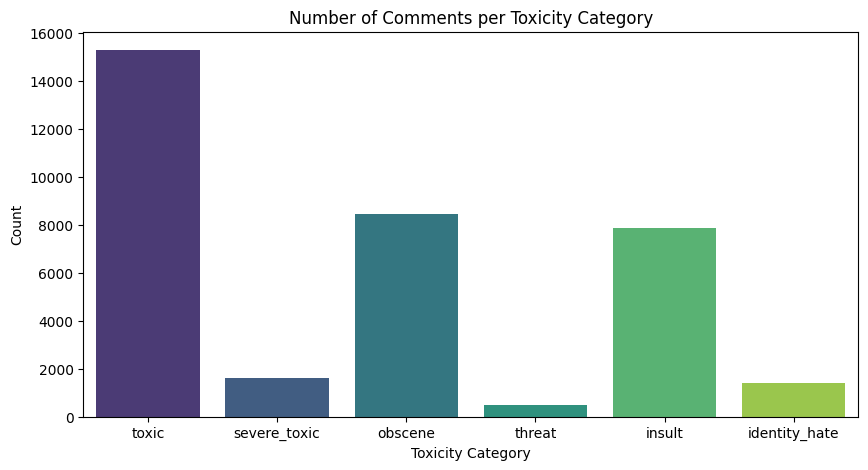

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, palette='viridis')
plt.title('Number of Comments per Toxicity Category')
plt.ylabel('Count')
plt.xlabel('Toxicity Category')
plt.show()

In [69]:
def count_sentences(text):
    return len(sent_tokenize(text))

def count_tokens(text):
    return len(word_tokenize(text))

# Precompute counts (efficient)
train["n_sentences"] = train['comment_text'].apply(count_sentences)
train["n_tokens"] = train['comment_text'].apply(count_tokens)

stats_per_class = {}
stats_per_class_no = {}


In [71]:
for categorie in categories:
    subset = train[train[categorie] == 1]
    
    stats_per_class[categorie] = {
        "num_samples": len(subset),
        "num_sentences": subset["n_sentences"].sum(),
        "num_tokens": subset["n_tokens"].sum(),
        "avg_sentences": subset["n_sentences"].mean(),
        "avg_tokens": subset["n_tokens"].mean(),
        "median_tokens": subset["n_tokens"].median()
    }

subset = train[train[categorie] == 0]
stats_per_class_no["non-toxic"] = {
        "num_samples": len(subset),
        "num_sentences": subset["n_sentences"].sum(),
        "num_tokens": subset["n_tokens"].sum(),
        "avg_sentences": subset["n_sentences"].mean(),
        "avg_tokens": subset["n_tokens"].mean(),
        "median_tokens": subset["n_tokens"].median()
    }

stats_df = pd.DataFrame(stats_per_class).T
stats_df_no = pd.DataFrame(stats_per_class).T

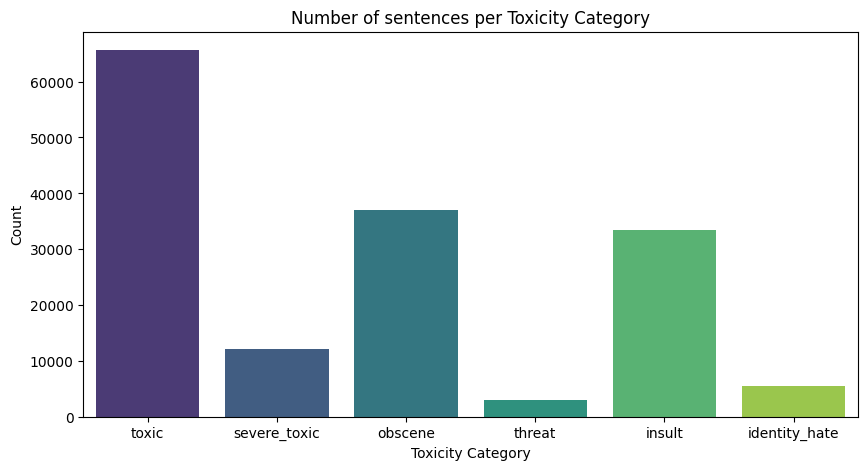

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(x=stats_df.index, y=stats_df["num_sentences"].values, hue=stats_df.index, palette='viridis')
plt.title('Number of sentences per Toxicity Category')
plt.ylabel('Count')
plt.xlabel('Toxicity Category')
plt.show()

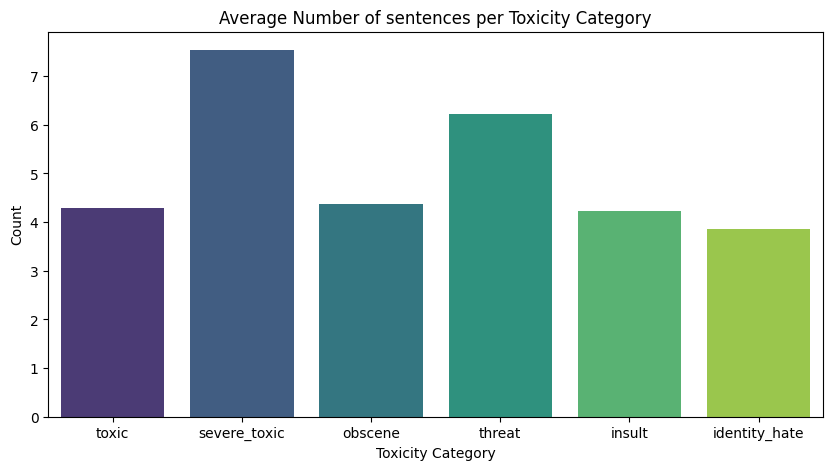

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=stats_df.index, y=stats_df["avg_sentences"].values, hue=stats_df.index, palette='viridis')
plt.title('Average Number of sentences per Toxicity Category')
plt.ylabel('Count')
plt.xlabel('Toxicity Category')
plt.show()

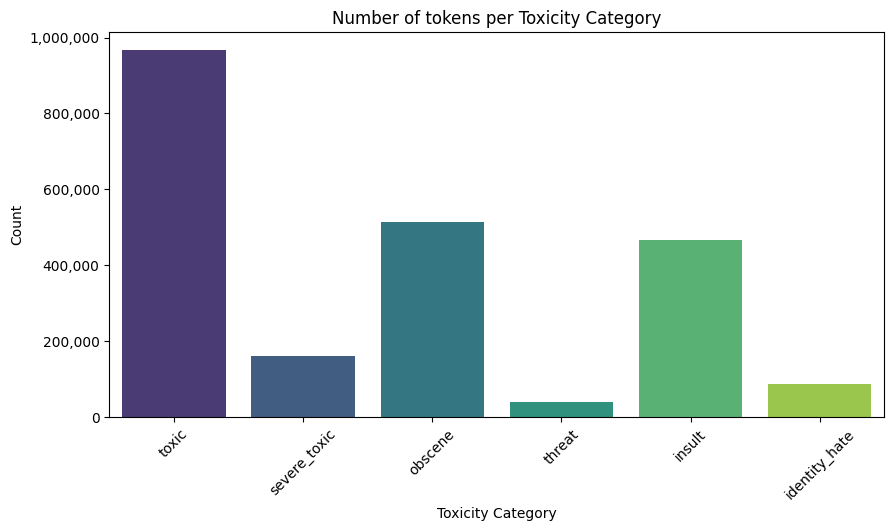

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=stats_df.index,
    y=stats_df["num_tokens"].values,
    hue=stats_df.index,
    palette="viridis"
)
plt.title("Number of tokens per Toxicity Category")
plt.ylabel("Count")
plt.xlabel("Toxicity Category")
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)
plt.show()

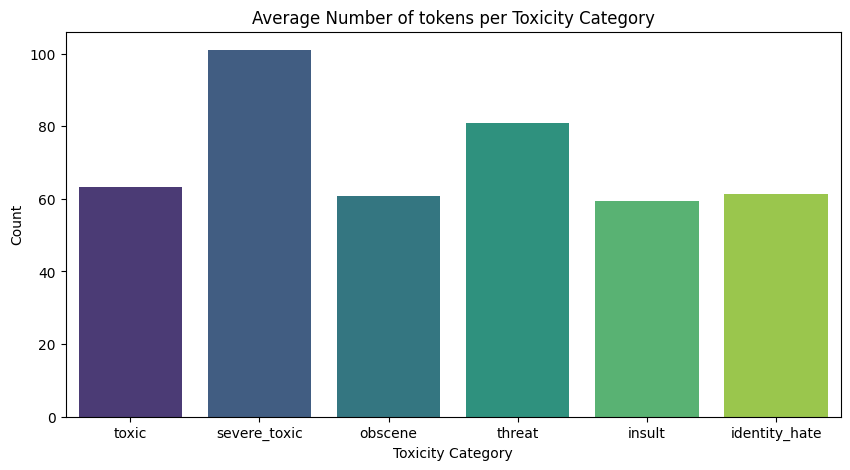

In [39]:
plt.figure(figsize=(10, 5))
sns.barplot(x=stats_df.index, y=stats_df["avg_tokens"].values, hue=stats_df.index, palette='viridis')
plt.title('Average Number of tokens per Toxicity Category')
plt.ylabel('Count')
plt.xlabel('Toxicity Category')
plt.show()

In [60]:
stats_df['num_samples'] = stats_df['num_samples'].astype('int')
stats_df['num_sentences'] = stats_df['num_sentences'].astype('int')
stats_df['num_tokens'] = stats_df['num_tokens'].astype('int')

In [61]:
stats_df.loc["non-toxic", ["num_samples", "num_sentences", "num_tokens"]].to_frame()

,non-toxic
num_samples,158166
num_sentences,696321
num_tokens,12740353


### 4.2 Toxic vs Non-toxic comparison

In [40]:
row_sums = train[categories].sum(axis=1)
non_toxic_comments_count = (row_sums == 0).sum()
toxic_comments_count = (row_sums > 0).sum()

labels = ['Non-toxic', 'Toxic (Any category)']
counts = [non_toxic_comments_count, toxic_comments_count]

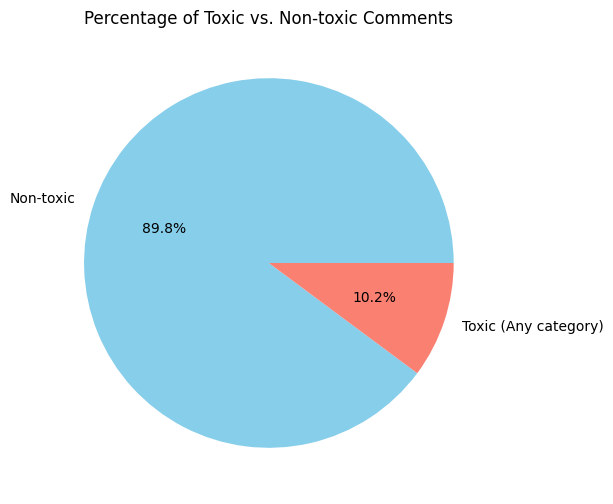

In [41]:
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Percentage of Toxic vs. Non-toxic Comments')
plt.show()

### 4.3 Correlation between toxicity categories

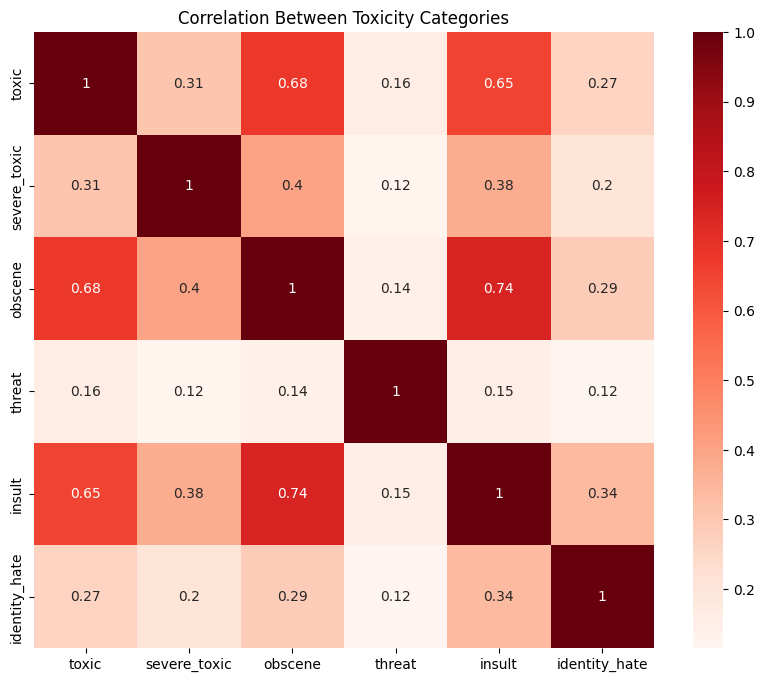

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(train[categories].corr(), annot=True, cmap='Reds')
plt.title('Correlation Between Toxicity Categories')
plt.show()

### 4.4 Number of sentences

In [43]:
# Function to count sentences
def count_sentences(text):
    if pd.isnull(text):
        return 0
    # sent_tokenize splits the text into a list of sentences
    return len(sent_tokenize(text))

In [44]:
train['sentence_count'] = train['comment_text'].apply(count_sentences)

In [45]:
train[['comment_text', 'sentence_count']].head()

,comment_text,sentence_count
0,Explanation\nWhy the edits made under my usern...,3
1,D'aww! He matches this background colour I'm s...,4
2,"Hey man, I'm really not trying to edit war. It...",3
3,"""\nMore\nI can't make any real suggestions on ...",4
4,"You, sir, are my hero. Any chance you remember...",2


In [48]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer", "tagger"])
nlp.add_pipe('sentencizer')

def count_sentences_spacy(text):
    if pd.isnull(text):
        return 0
    doc = nlp(text)
    return len(list(doc.sents))

In [49]:
train['sentence_count_spacy'] = train['comment_text'].iloc[:15000].apply(count_sentences_spacy)

In [ ]:
train['sentence_count_spacy'] = train['comment_text'].apply(count_sentences_spacy)

In [ ]:
train[['sentence_count_spacy','sentence_count']].describe()

,sentence_count_spacy,sentence_count
count,159571.000000,159571.000000
mean,4.460873,4.397604
std,7.321445,6.830832
min,1.000000,1.000000
25%,2.000000,2.000000
50%,3.000000,3.000000
75%,5.000000,5.000000
max,683.000000,683.000000


Since both approaches to count the number of sentences by comment doesnt show a meaningful difference, the fastest way (nlt) will be used.

In [ ]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sentence_count,sentence_count_spacy
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,3,3
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,4,4
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,3,3
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,4,5
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,2,2


In [78]:
category_means = {}

for cat in categories:
    # Filter only rows where this category is 1, then take the mean of sentence_count
    category_means[cat] = train[train[cat] == 1]['sentence_count'].mean()

# 3. Add 'non-toxic' comments for comparison
non_toxic_mean = train[train[categories].sum(axis=1) == 0]['sentence_count'].mean()
category_means['non-toxic'] = non_toxic_mean

# 4. Convert to a Series for a nice display
mean_series = pd.Series(category_means).sort_values(ascending=False)

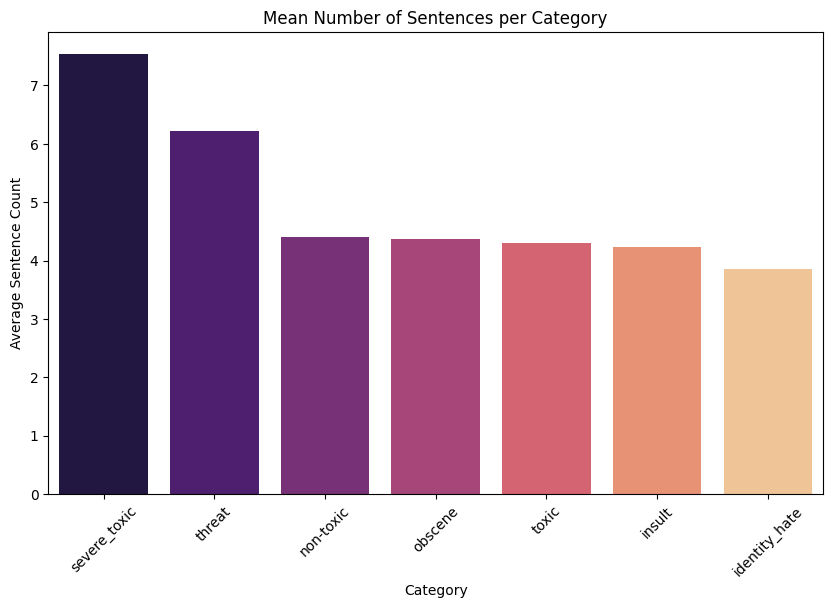

In [79]:
plt.figure(figsize=(10, 6))
sns.barplot(x=mean_series.index, y=mean_series.values, hue=mean_series.index, palette='magma')

plt.title('Mean Number of Sentences per Category')
plt.ylabel('Average Sentence Count')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()

### 4.5 Token count

In [80]:
train['token_count'] = train['comment_text'].apply( lambda x: len(word_tokenize(str(x))) )

In [81]:
category_token_means = {}

for cat in categories:
    category_token_means[cat] = train[train[cat] == 1]['token_count'].mean()

# non-toxic
non_toxic_mean = train[train[categories].sum(axis=1) == 0]['token_count'].mean()
category_token_means['non_toxic'] = non_toxic_mean

token_mean_series = pd.Series(category_token_means).sort_values(ascending=False)

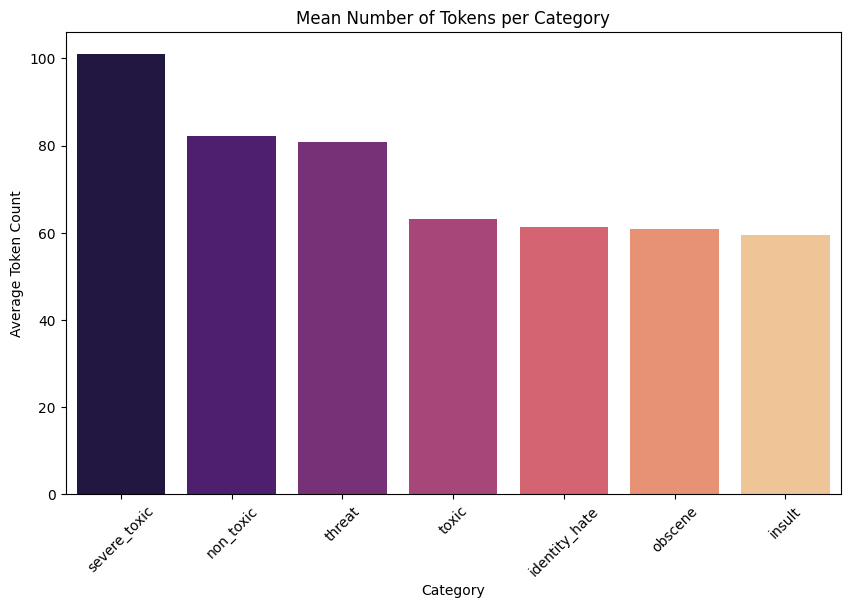

In [82]:
plt.figure(figsize=(10, 6))
sns.barplot(x=token_mean_series.index, y=token_mean_series.values, hue=token_mean_series.index, palette='magma')

plt.title('Mean Number of Tokens per Category')
plt.ylabel('Average Token Count')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()

In [83]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(str(text))
    filtered = [w for w in tokens if w.lower() not in stop_words]
    return " ".join(filtered)

train['comment_no_stop'] = train['comment_text'].apply(remove_stopwords)

In [84]:
train['token_count_nsw'] = train['comment_no_stop'].apply( lambda x: len(word_tokenize(str(x))) )
category_token_means_nsw = {}

for cat in categories:
    category_token_means_nsw[cat] = train[train[cat] == 1]['token_count_nsw'].mean()

# non-toxic
non_toxic_mean_nsw = train[train[categories].sum(axis=1) == 0]['token_count_nsw'].mean()
category_token_means_nsw['non_toxic'] = non_toxic_mean_nsw

token_mean_series_nsw = pd.Series(category_token_means_nsw).sort_values(ascending=False)

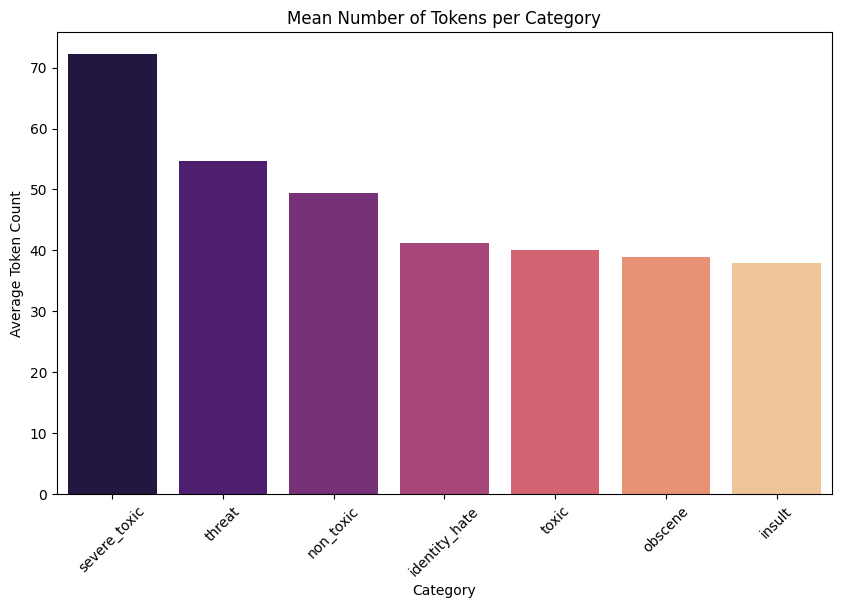

In [85]:
plt.figure(figsize=(10, 6))
sns.barplot(x=token_mean_series_nsw.index, y=token_mean_series_nsw.values, hue=token_mean_series_nsw.index, palette='magma')

plt.title('Mean Number of Tokens per Category')
plt.ylabel('Average Token Count')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()

### 4.6 Comment length

In [86]:
# Create a column for comment length
train['char_length'] = train['comment_text'].apply(len)

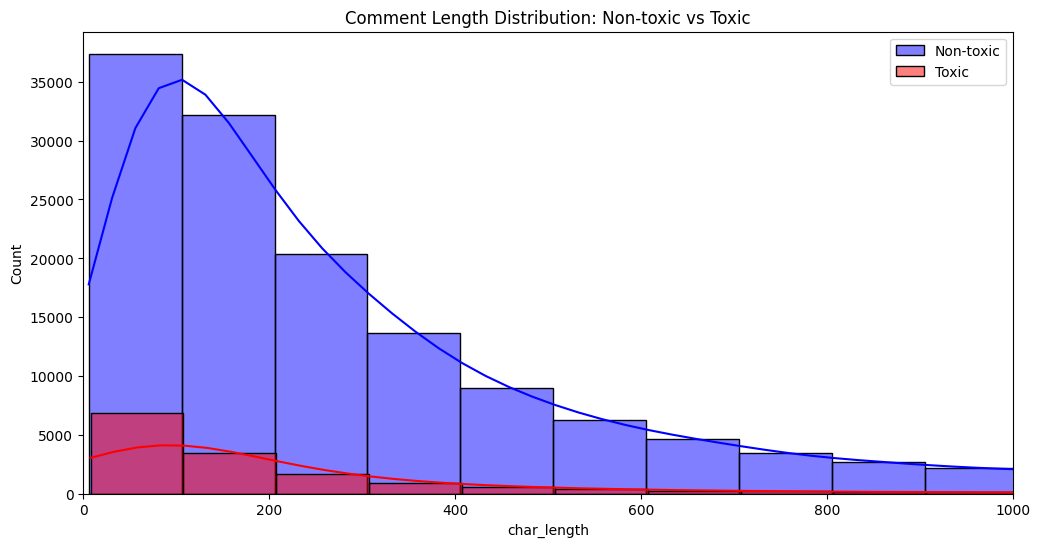

In [87]:
# Plot length distribution for Toxic vs Non-toxic
plt.figure(figsize=(12, 6))
sns.histplot(train[train['toxic']==0]['char_length'], label='Non-toxic', color='blue', kde=True, bins=50)
sns.histplot(train[train['toxic']==1]['char_length'], label='Toxic', color='red', kde=True, bins=50)
plt.xlim(0, 1000) # Limiting to 1000 chars for better visibility
plt.legend()
plt.title('Comment Length Distribution: Non-toxic vs Toxic')
plt.show()

In [88]:
def count_caps(text):
    return sum(1 for c in text if c.isupper())

train['cap_count'] = train['comment_text'].apply(count_caps)
train['cap_ratio'] = train['cap_count'] / train['char_length']

# Compare cap_ratio for toxic vs non-toxic
print("Average Cap Ratio (Non-toxic):", train[train['toxic']==0]['cap_ratio'].mean())
print("Average Cap Ratio (Toxic):", train[train['toxic']==1]['cap_ratio'].mean())

Average Cap Ratio (Non-toxic): 0.04494893971457749
Average Cap Ratio (Toxic): 0.1145746881122181


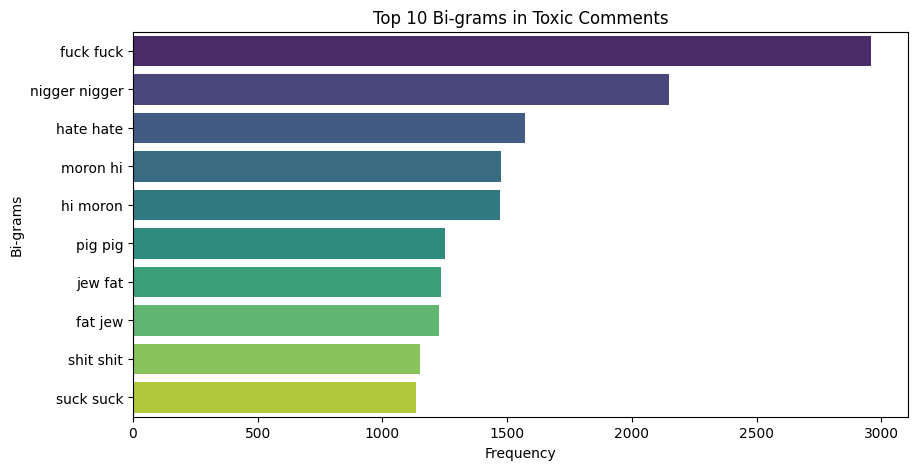

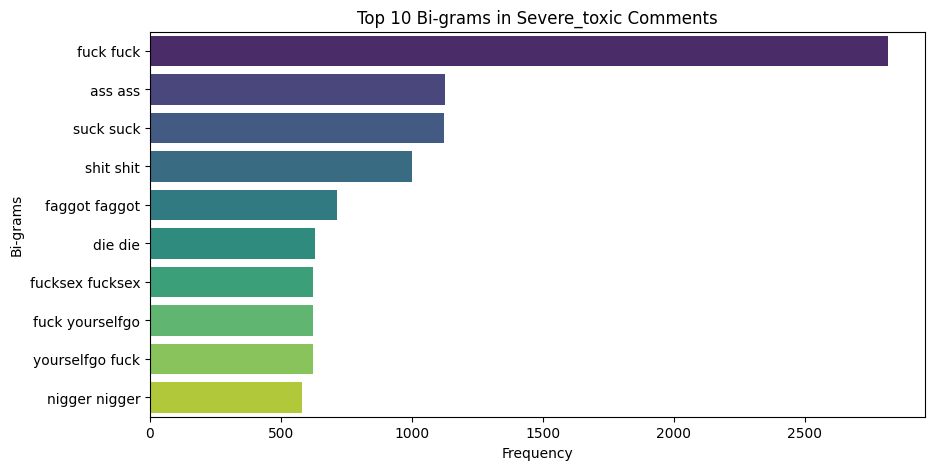

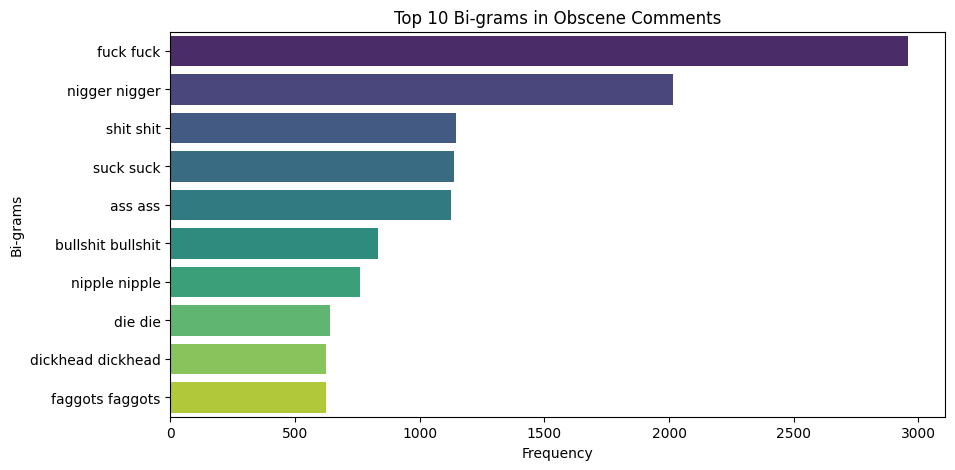

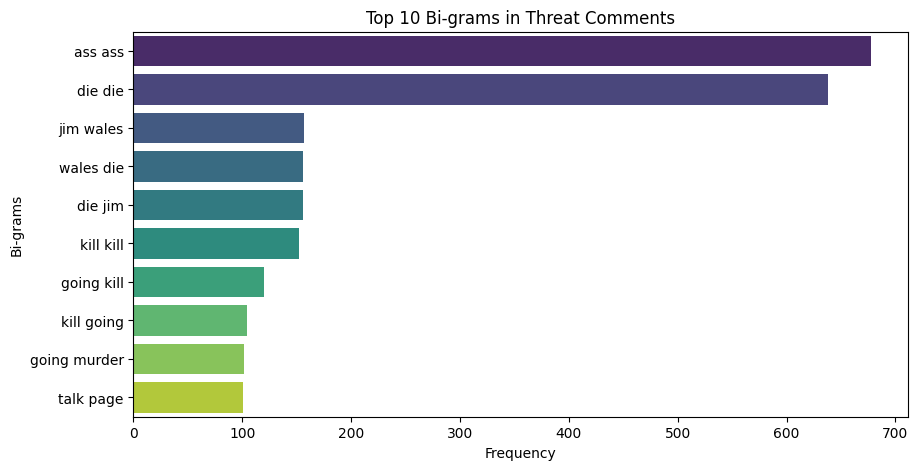

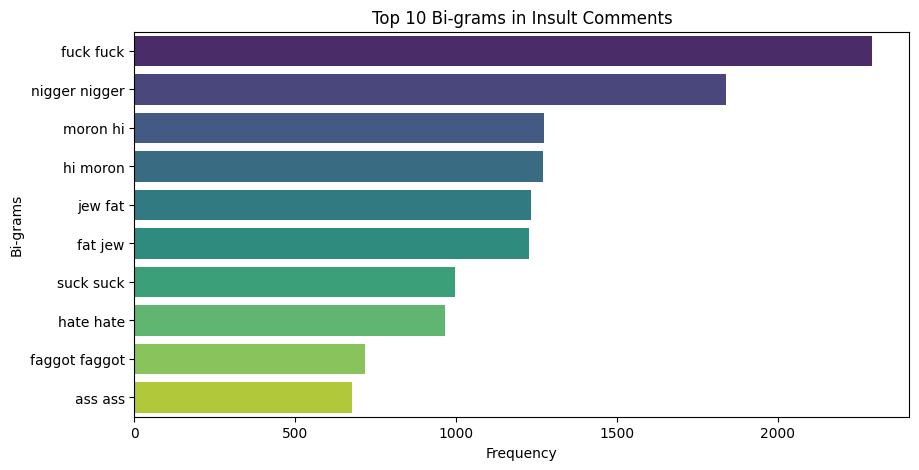

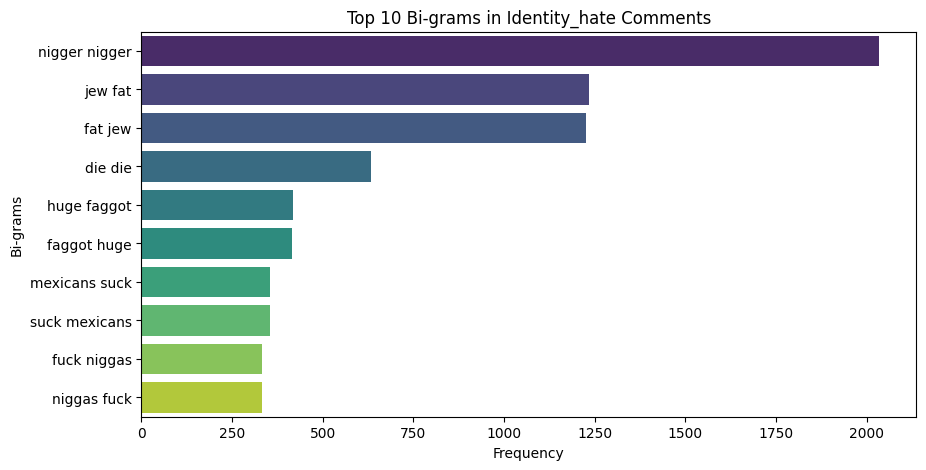

In [94]:
def get_top_n_words(corpus, n=10, g=1):
    vec = CountVectorizer(ngram_range=(g, g), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# Loop through each toxicity category column
categories = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

for cat in categories:
    # Filter comments belonging to this category
    corpus = train[train[cat] == 1]["comment_text"]
    
    # Get top bigrams
    top_bigrams = get_top_n_words(corpus, n=10, g=2)
    words, counts = zip(*top_bigrams)
    
    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis", hue=list(words))
    plt.title(f"Top 10 Bi-grams in {cat.capitalize()} Comments")
    plt.xlabel("Frequency")
    plt.ylabel("Bi-grams")
    plt.show()

### Most common words

In [90]:
def get_top_words(texts, n=5):
    all_tokens = []

    for doc in nlp.pipe(texts, batch_size=50):
        tokens = [
            token.text.lower()
            for token in doc
            if not token.is_stop 
            and not token.is_punct 
            and token.is_alpha
        ]
        all_tokens.extend(tokens)

    return Counter(all_tokens).most_common(n)

In [91]:
top_words_per_category = {}

for cat in categories:
    texts = train[train[cat] == 1]['comment_no_stop']
    top_words_per_category[cat] = get_top_words(texts)

# Non-toxic
non_toxic_texts = train[train[categories].sum(axis=1) == 0]['comment_no_stop']
top_words_per_category['non_toxic'] = get_top_words(non_toxic_texts)

In [92]:
for cat, words in top_words_per_category.items():
    print(f"\n{cat}:")
    for word, count in words:
        print(f"  {word}: {count}")


toxic:
  fuck: 9591
  shit: 3619
  like: 3510
  wikipedia: 3423
  nigger: 3299

severe_toxic:
  fuck: 6966
  suck: 2534
  ass: 2114
  shit: 1883
  faggot: 1571

obscene:
  fuck: 9517
  shit: 3209
  fucking: 3114
  suck: 3018
  ass: 2844

threat:
  die: 1167
  ass: 772
  kill: 504
  going: 294
  block: 170

insult:
  fuck: 7582
  suck: 2790
  nigger: 2780
  fucking: 2720
  ass: 2210

identity_hate:
  nigger: 2968
  fat: 1321
  jew: 1313
  gay: 915
  fuck: 879

non_toxic:
  article: 55902
  page: 43954
  wikipedia: 42476
  talk: 34409
  like: 24189


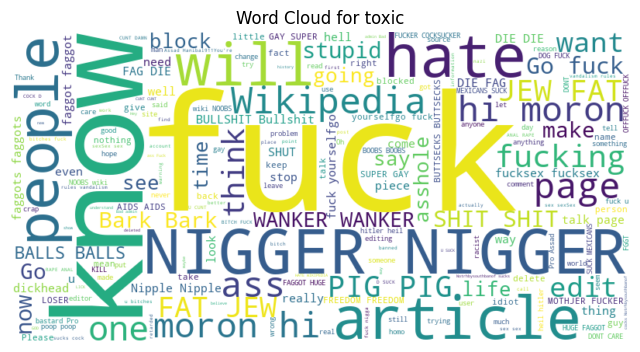

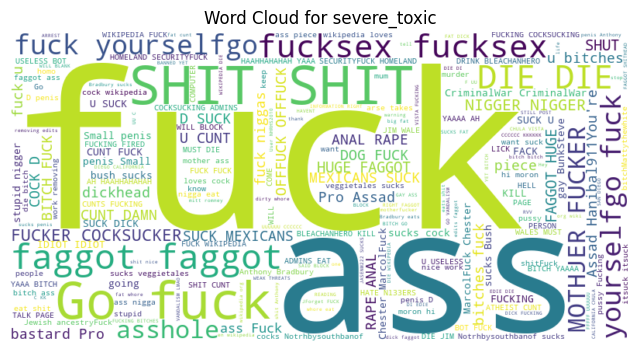

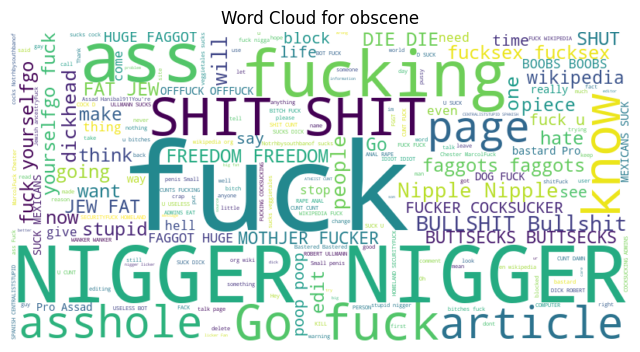

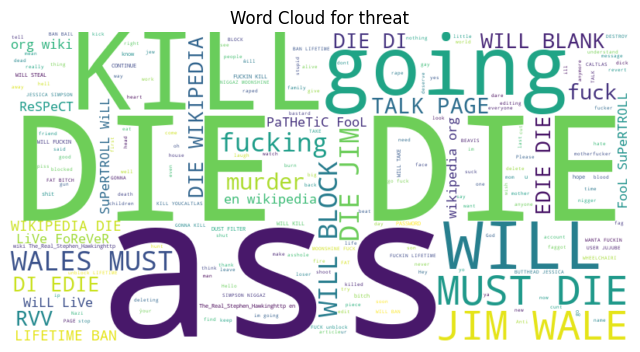

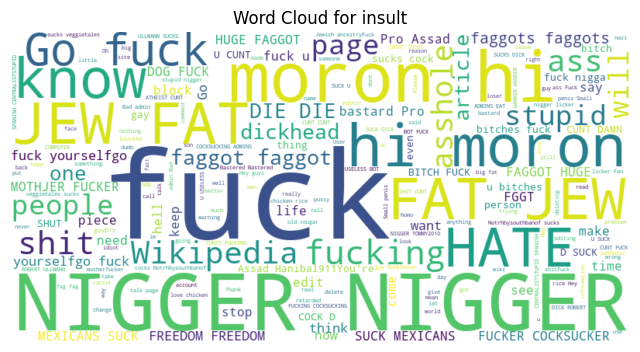

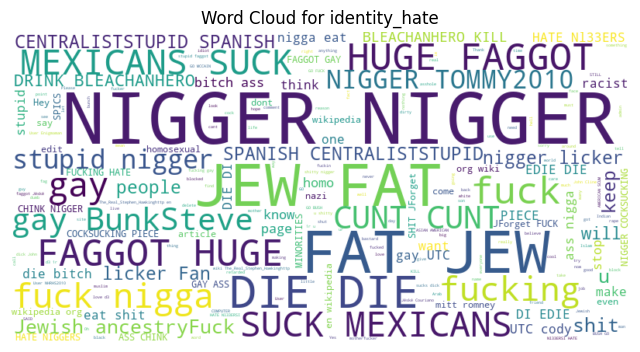

In [98]:
for cat in categories:
    # Filter comments belonging to this category
    text = " ".join(train[train[cat] == 1]["comment_text"].astype(str))
    
    # Create the word cloud object
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=None,   # you can pass a set of stopwords if needed
        colormap="viridis"  # choose a color map
    ).generate(text)

    # Plot the word cloud
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {cat}")
    plt.show()

End of notebook